# Transverse Field Ising Model (TFIM) evolution using Pauli Propagation

In [80]:
# using Pkg; Pkg.add("PauliPropagation")

In [81]:
using PauliPropagation

using LinearAlgebra
using Plots

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# 1. Introduction

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex circuits.

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

We will discretize the time, and a layer is applied every $dt=0.1$ time step.

In [82]:
dt = 0.1

# Brick layer topology exemple
nqubits = 4
topology = bricklayertopology(nqubits; periodic=false)

3-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (3, 4)
 (2, 3)

Each layer consists of nearest-neighbor gates of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ which is, in our case $dt$, a fixed parameter (Trotter step).


This type of circuit corresponds to a Trotterized time evolution under an TFIM Hamiltonian:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

$i$ and $j$ are the topological tuples $(i, j)$, so they are the nearest neighbors here

In [83]:
function TFIM_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
      topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      rxxlayer!(circuit, topology)
    end
    return circuit
end

TFIM_circuit (generic function with 1 method)

In [84]:
# Circuit exemple
nlayers = 5
circuit = TFIM_circuit(nqubits, nlayers; topology)
parameters = ones(countparameters(circuit)) * dt # all the \theta are dt

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 15


---

## 1.1 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [85]:
# Observable exemple
Z_2 = PauliString(nqubits, :Z, 2) # IZI...I
observable = Z_2

PauliString(nqubits: 4, 1.0 * IZII)

---

## 1.2 Pauli propagation method

The key idea of Pauli propagation is to express the observable as a sum of Pauli strings:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings. This leads to a growth in the number of terms, which is controlled in practice using:

- truncation of small coefficients
- limitation of the Pauli weight

This method is particularly efficient when the operator remains relatively sparse in the Pauli basis.

Here we want to verify the implementation : we don't apply truncation.

In [86]:
# truncations exemple
max_weight = 3 # the max is nqubits
min_abs_coeff = 1e-4

0.0001

Propagating a Pauli string through a circuit transforms it into a Pauli sum.

We can use the `propagate` function from the package directly, but in the rest of this notebook we will use my `propagate_layerbylayer` function, which allows us to calculate the evolution of some physical quantity.

In [87]:
# propagation exemple
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 4, 4 Pauli terms:
 -0.22985 * XZXI
 0.42074 * XYII
 0.77015 * IZII
 0.42074 * IYXI
)

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the norm of the observable, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [88]:
norm = pp.pauli_norm(pauli_sum)

1.0000000000000013

---

# 2. Quantities and measurements

## 2.1 Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha |c_\alpha|^2 log(|c_\alpha|^2)$$

In [89]:
entropy = pp.pauli_entropy(pauli_sum)

1.0781872743987904

---

## 2.2 Overlap with the intial state $|0\rangle$

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha$, the pauli string $P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [90]:
function compute_overlap(pauli_sum::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in pauli_sum
      string = pp.decode_pauli(pauli_string, pauli_sum.nqubits)
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_overlap (generic function with 1 method)

But in this package we have a function `overlapwithzero()` which does exactly the same thing :

In [91]:
overlap1 = compute_overlap(pauli_sum)
overlap2 = overlapwithzero(pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

# 3. Verification of the correct implementation of the method

## 3.1 Initialisation for the PauliPropagation method

Initialisation of the circuit :

In [92]:
nqubits = 9
topology = bricklayertopology(nqubits; periodic=false)

nlayers = 150
circuit = TFIM_circuit(nqubits, nlayers; topology)

parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value dt

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 1200


Initialisation of the observable as a Pauli string

In [93]:
i = 2
Z_i_pauliString = PauliString(nqubits, :Z, i) # IZI...I
observable = Z_i_pauliString

PauliString(nqubits: 9, 1.0 * IZIIIIIII)

## 3.2 Propagation with the PauliPropagation method

Next, we will verify our method by comparing the time-dependent overlap of a $\psi_0$ state ($\langle \psi_0 | \hat O(t) | \psi_0\rangle$) with the exact method. Therefore, we need to pass this information to the `propagate_layerbylayer` function.

In [94]:
ψ0 = append!([1.],[0. for _ in 2:(2^nqubits)])

max_weight = typemax(Int)   # no limit
min_abs_coeff = 0.0         # no truncations

Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

# we compute the matrix form of the pauli sum
Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

println("We compute the overlap in terms of time with the state ψ0 = ", ψ0, " = |up ... up up >")

layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003747224807739258 seconds
We compute the overlap in terms of time with the state ψ0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

## 3.3 Exact result

We can calculate the same circuit analytically and compare our results :

In [95]:
Z_i = ext.get_Zi(nqubits, i)
circuit_exact = ext.circuit_TFIM(nqubits, dt, nlayers)

Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i; ψ0)

println("We compute the overlap in terms of time with the state ψ0 = ", ψ0, " = |up ... up up >")

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 11.853477001190186 seconds
We compute the overlap in terms of time with the state ψ0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0

## 3.4 Result

In [96]:
is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  1.0010726896875643e-13


We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-13}$ with $150$ evolution steps.

Numerical error is calculate with the LinearAlgebra.jl function, `opnorm(A)`, corresponding to the spectral norm :
$$||A||_2 = \sqrt{\lambda_{max} (A^\dagger A) } = \sigma_{max}(A) $$

$Z_i(t_{final})$ :

In [97]:
Zi_t_exact

512×512 Matrix{ComplexF64}:
     0.577126+0.0im          …           0.0+0.0im
          0.0+0.0im             -3.42904e-16+0.0im
          0.0+0.0im                      0.0-3.67613e-16im
          0.0+5.34058e-16im              0.0+0.0im
          0.0+0.0im              5.32055e-16+0.0im
  6.68039e-16+0.0im          …           0.0+0.0im
          0.0-1.89109e-15im              0.0+0.0im
          0.0+0.0im                      0.0+1.72025e-15im
          0.0+0.0im                      0.0+1.58526e-16im
          0.0-1.56115e-15im              0.0+0.0im
 -4.85246e-17+0.0im          …           0.0+0.0im
          0.0+0.0im              4.85987e-16+0.0im
          0.0-2.00363e-15im              0.0+0.0im
             ⋮               ⋱  
 -1.88586e-16+0.0im          …           0.0+0.0im
          0.0+0.0im              9.95731e-16+0.0im
          0.0+0.0im                      0.0+6.61004e-16im
          0.0-2.19056e-16im              0.0+0.0im
          0.0-2.15674e-15im             

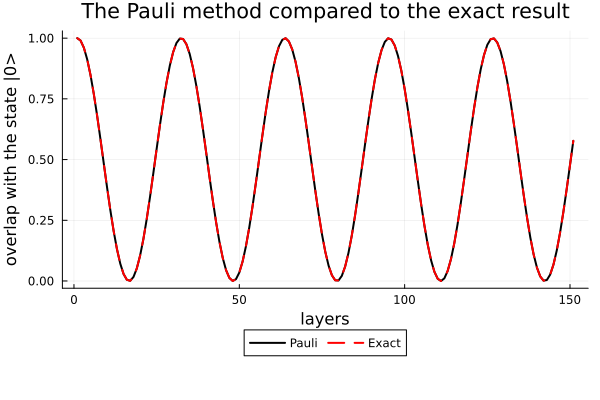

In [98]:
overlap_pp = result_pp["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="The Pauli method compared to the exact result", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, overlap_pp, label="Pauli", line = (2, :solid), color=:black)
plot!(p, overlap_exact, label="Exact", line = (2, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

We obtain the same curve along the $150$ evolution steps.

---

# 4. Truncations test

## 4.1 Max Weight

In [99]:
max_weight_list = 3:2:nqubits
min_abs_coeff = 1e-4

overlap_max_weight, norm_max_weight = Vector{Float64}[], Vector{Float64}[]
for max_weight in max_weight_list
  println("---")
  println("Max weight = ", max_weight)
  # propagation
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

  # result
  push!(overlap_max_weight, result_pp["overlap"])
  push!(norm_max_weight, result_pp["norm"])

  # print difference between Zi(t)
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)
  is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
  println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)
  error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
  println("with an error of :  ", error_val)
end

---
Max weight = 3
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.004123210906982422 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  1.9586802738542642e-5
---
Max weight = 5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003343820571899414 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  1.9586802738542642e-5
---
Max weight = 7
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer :

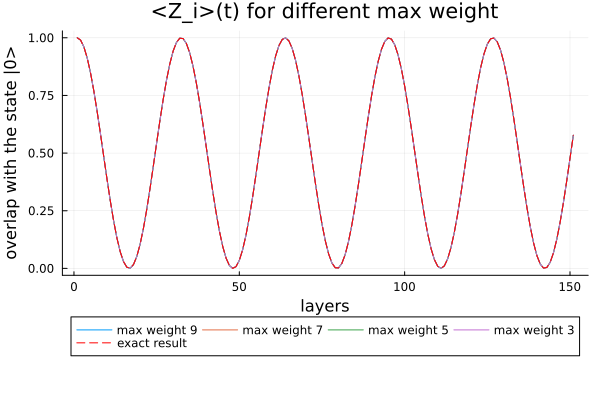

In [100]:
p = plot(title="<Z_i>(t) for different max weight", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_max_weight))
    plot!(p, 1:length(overlap), overlap, label="max weight $(reverse(max_weight_list)[i])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(overlap_max_weight))

display(p)

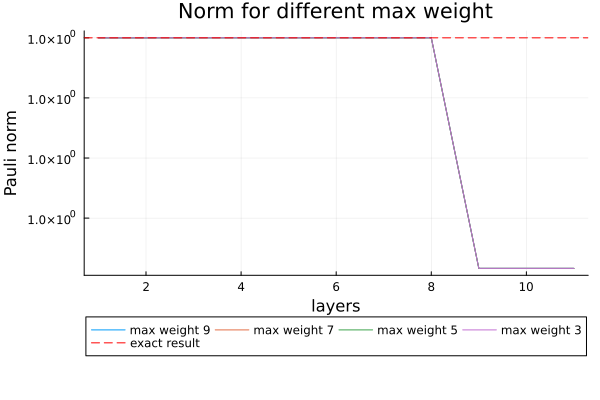

In [101]:
p = plot(title="Norm for different max weight", xlabel="layers", ylabel="Pauli norm")

for (i, norm) in enumerate(reverse(norm_max_weight))
    plot!(p, 1:length(norm), norm, label="max weight $(reverse(max_weight_list)[i])")
end
hline!([1], label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(norm_max_weight))

display(p)

---

## 4.2 Min abs coeff

In [102]:
max_weight = 3
min_abs_coeff_idx = round.(Int, range(4, 8, 4))
min_abs_coeff_list = 10.0 .^ .-min_abs_coeff_idx

overlap_min_abs_coeff, norm_min_abs_coeff = Vector{Float64}[], Vector{Float64}[]
for min_abs_coeff in min_abs_coeff_list
  println("---")
  println("Min abs coeff = ", min_abs_coeff)
  # propagation
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

  # result
  push!(overlap_min_abs_coeff, result_pp["overlap"])
  push!(norm_min_abs_coeff, result_pp["norm"])

  # print difference between Zi(t)
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)
  is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
  println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)
  error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
  println("with an error of :  ", error_val)
end

---
Min abs coeff = 0.0001
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003306865692138672 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  1.9586802738542642e-5
---
Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0031309127807617188 seconds
Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  1.0010726896875643e-13
---
Min abs coeff = 1.0000000000000001e-7
layer : 15/150 complete
layer : 30/150 

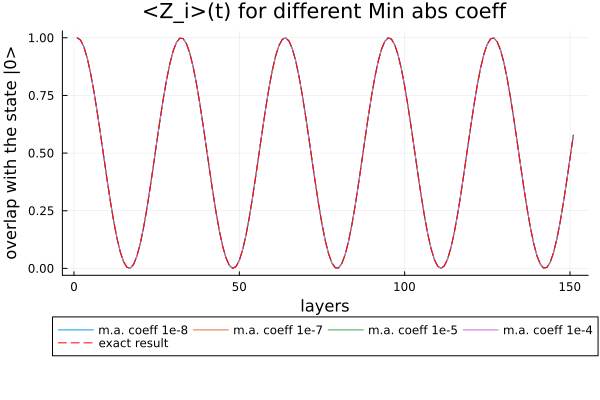

In [103]:
p = plot(title="<Z_i>(t) for different Min abs coeff", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_min_abs_coeff))
    plot!(p, 1:length(overlap), overlap, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(overlap_min_abs_coeff))

display(p)

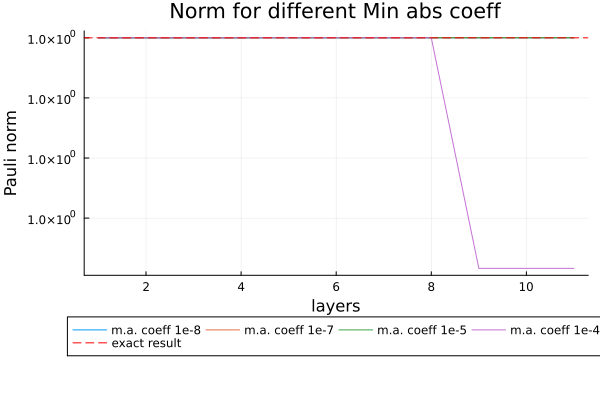

In [104]:
p = plot(title="Norm for different Min abs coeff", xlabel="layers", ylabel="Pauli norm")

for (i, norm) in enumerate(reverse(norm_min_abs_coeff))
    plot!(p, 1:length(norm), norm, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
hline!([1], label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(norm_min_abs_coeff))

display(p)

In [105]:
Zi_t_pauli_propagation

PauliSum(nqubits: 9, 4 Pauli terms:
 -0.42287 * XZXIIIIII
 -0.49402 * XYIIIIIII
 0.57713 * IZIIIIIII
 -0.49402 * IYXIIIIII
)

---

# 5. Conclusion

We can see that for this type of circuit, our result remains very close.

This is because the Pauli strings do not become complex in this type of circuit, so truncation has very little effect, which prevents our results from diverging from the case without truncation.

The Pauli propagation method works very well in this case and saves us significant computation time compared to the exact method, which is no small advantage.

---

# Annexe

### Plot of the pauli entropy

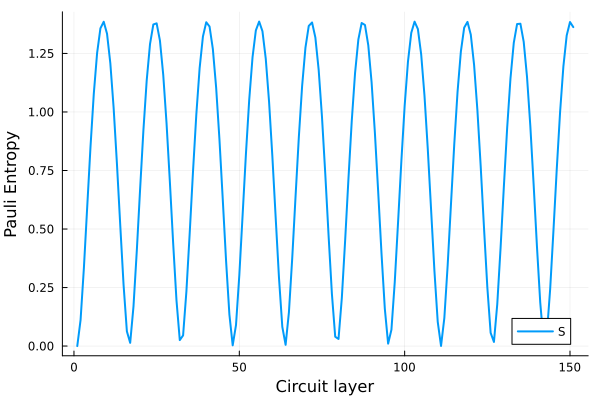

In [106]:
entropy = result_pp["S"]
plot(entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)